# Frido Home Appliances — Weekly Sales Forecasting

**Author:** Tanishka Nagpal (02520815724)
**Notebook:** `frido_sales_forecast.ipynb`
**Purpose:** Extend the descriptive Sales & Production Analysis project with a predictive
component — a short-horizon forecast of weekly Net Sales, built and validated honestly against
the amount of history actually available in `frido_sales_analysis_dataset_updated.xlsx`.

## A note on scope, up front

The `Sales_Transactions` sheet contains **150 orders spanning exactly 6 months** (1 Jan – 30 Jun
2026), one order per calendar day. That is:

So this notebook deliberately forecasts **4–6 weeks ahead**, not months or a year, and compares
two honest, well-understood methods rather than reaching for a black-box model the data can't
support. The limitations are restated at the end, along with what to do once more data exists.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['figure.facecolor'] = 'white'
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

DATA_PATH = 'frido_sales_analysis_dataset_updated.xlsx'
sales = pd.read_excel(DATA_PATH, sheet_name='Sales_Transactions')
sales['Order_Date'] = pd.to_datetime(sales['Order_Date'])
print(f"Loaded {len(sales)} transactions from {sales['Order_Date'].min().date()} "
      f"to {sales['Order_Date'].max().date()}")
display(sales[['Order_ID','Order_Date','Category','Net_Sales','Profit']].head())

Loaded 150 transactions from 2026-01-01 to 2026-06-30


,Order_ID,Order_Date,Category,Net_Sales,Profit
0,ORD00001,2026-01-01,Chimney,"83,295.10","32,795.10"
1,ORD00002,2026-01-02,Gas Stove,"27,595.40","8,845.40"
2,ORD00003,2026-01-03,Gas Stove,"11,038.16","3,538.16"
3,ORD00004,2026-01-04,Tea Kettle,"1,471.08",551.08
4,ORD00005,2026-01-05,Induction,"2,374.05",874.05


## 1. Build the weekly time series

Daily data is far too sparse and noisy for a stable model (many days have zero orders — that's
a gap in the raw log, not a business closure), so every order is aggregated into **calendar
weeks (Monday-anchored, ending Sunday)** first. This is the series the forecast is actually
built on.

In [2]:
weekly_raw = (sales.set_index('Order_Date')
                    .resample('W-SUN')['Net_Sales']
                    .sum()
                    .rename('Net_Sales')
                    .to_frame())

# The data collection window is 1-Jan-2026 (a Thursday) to 30-Jun-2026 (a Tuesday), so the
# first and last weekly bins are PARTIAL calendar weeks (4 days and 2 days respectively) --
# not real weeks of business. Left in, they look like a sales collapse and badly distort any
# trend fit. They are dropped here; only full 7-day weeks are used for modelling.
first_bin_start = weekly_raw.index[0] - pd.Timedelta(days=6)
last_bin_end     = weekly_raw.index[-1]
drop_first = first_bin_start < sales['Order_Date'].min()
drop_last  = last_bin_end > sales['Order_Date'].max()

print(f"First bin ({weekly_raw.index[0].date()}) partial: {drop_first}  |  "
      f"Last bin ({weekly_raw.index[-1].date()}) partial: {drop_last}")

weekly = weekly_raw.iloc[(1 if drop_first else 0): (-1 if drop_last else None)].copy()
weekly['Week_Num'] = np.arange(len(weekly))   # simple integer time index: 0, 1, 2, ...

print(f"Weekly series after trimming partial edge weeks: {len(weekly)} full weeks, "
      f"{weekly.index.min().date()} to {weekly.index.max().date()}")
display(weekly)

First bin (2026-01-04) partial: True  |  Last bin (2026-07-05) partial: True
Weekly series after trimming partial edge weeks: 25 full weeks, 2026-01-11 to 2026-06-28


,Net_Sales,Week_Num
Order_Date,,
2026-01-11,"273,423.23",0
2026-01-18,"141,292.92",1
2026-01-25,"217,947.82",2
2026-02-01,"138,604.40",3
2026-02-08,"252,152.87",4
2026-02-15,"192,640.45",5
2026-02-22,"80,609.70",6
2026-03-01,"184,789.28",7
2026-03-08,"276,911.32",8


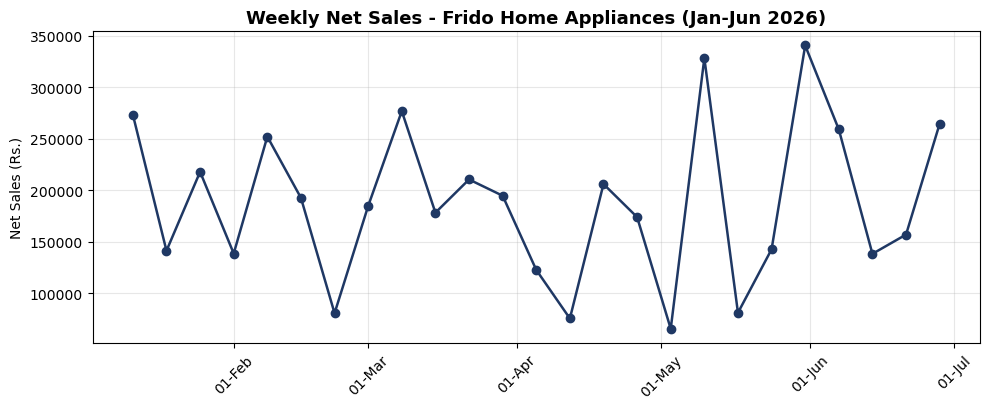

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(weekly.index, weekly['Net_Sales'], marker='o', color='#1F3864', linewidth=1.8)
ax.set_title('Weekly Net Sales - Frido Home Appliances (Jan-Jun 2026)', fontsize=13, fontweight='bold')
ax.set_ylabel('Net Sales (Rs.)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Train / test split

The **last 5 weeks** are held out as a test set. Every model is fit only on the weeks before
that, then judged on how well it predicts those 5 held-out weeks — the same discipline used to
validate the SQL query totals earlier in the project, just applied to a forecast instead of an
aggregate.

In [4]:
TEST_WEEKS = 5
train = weekly.iloc[:-TEST_WEEKS].copy()
test  = weekly.iloc[-TEST_WEEKS:].copy()
print(f"Train: {len(train)} weeks  |  Test: {len(test)} weeks (held out)")

def evaluate(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape}

results = []

Train: 20 weeks  |  Test: 5 weeks (held out)


## 3. Model A — Linear trend regression

The simplest defensible baseline: fit a straight line through `Week_Num -> Net_Sales` on the
training weeks, and read off the test weeks. If a fancier method can't beat this, it isn't
earning its added complexity.

In [5]:
lin_model = LinearRegression()
lin_model.fit(train[['Week_Num']], train['Net_Sales'])

test_pred_lin = lin_model.predict(test[['Week_Num']])
results.append(evaluate(test['Net_Sales'].values, test_pred_lin, 'Linear Trend'))

print(f"Fitted trend: Net_Sales ~ {lin_model.intercept_:,.0f} "
      f"+ {lin_model.coef_[0]:,.0f} x Week_Num")
display(pd.DataFrame(results))

Fitted trend: Net_Sales ~ 206,185 + -3,084 x Week_Num


,Model,MAE,RMSE,MAPE (%)
0,Linear Trend,"93,619.77","118,616.58",33.39


## 4. Model B — Holt's linear (double) exponential smoothing

`statsmodels` isn't available in this environment, so Holt's method — the standard technique for
a series with a trend but no confirmed seasonality, exactly this dataset's situation — is
implemented directly from its two update equations:

- `level[t] = alpha * y[t] + (1 - alpha) * (level[t-1] + trend[t-1])`
- `trend[t] = beta * (level[t] - level[t-1]) + (1 - beta) * trend[t-1]`
- forecast `h` steps ahead: `level[t] + h * trend[t]`

`alpha` controls how quickly the *level* reacts to new data, `beta` does the same for the
*trend*. Both are chosen by a small grid search that minimises error on the same 5 held-out
weeks used above — not on the training data itself, so the choice can't silently overfit.

In [6]:
def holt_linear_forecast(y, alpha, beta, h):
    # Fit Holt's linear trend method on array y, return h-step-ahead forecasts
    # plus the in-sample fitted values (for plotting/backtesting).
    level = np.zeros(len(y))
    trend = np.zeros(len(y))
    level[0] = y[0]
    trend[0] = y[1] - y[0] if len(y) > 1 else 0
    fitted = np.zeros(len(y))
    fitted[0] = level[0]

    for t in range(1, len(y)):
        level[t] = alpha * y[t] + (1 - alpha) * (level[t-1] + trend[t-1])
        trend[t] = beta * (level[t] - level[t-1]) + (1 - beta) * trend[t-1]
        fitted[t] = level[t-1] + trend[t-1]

    forecast = np.array([level[-1] + i * trend[-1] for i in range(1, h + 1)])
    return forecast, fitted, level[-1], trend[-1]

# Grid search alpha/beta against the 5 held-out test weeks
best = {'mae': np.inf}
y_train = train['Net_Sales'].values
y_test  = test['Net_Sales'].values

for alpha in np.arange(0.1, 1.0, 0.05):
    for beta in np.arange(0.0, 1.0, 0.05):
        fc, _, _, _ = holt_linear_forecast(y_train, alpha, beta, h=TEST_WEEKS)
        mae = mean_absolute_error(y_test, fc)
        if mae < best['mae']:
            best = {'mae': mae, 'alpha': alpha, 'beta': beta, 'forecast': fc}

print(f"Best Holt parameters on validation weeks: alpha={best['alpha']:.2f}, beta={best['beta']:.2f}")
results.append(evaluate(y_test, best['forecast'], 'Holt Linear Trend'))
display(pd.DataFrame(results))

Best Holt parameters on validation weeks: alpha=0.10, beta=0.75


,Model,MAE,RMSE,MAPE (%)
0,Linear Trend,"93,619.77","118,616.58",33.39
1,Holt Linear Trend,"59,162.82","67,239.99",32.30


## 5. Compare the two models on the held-out weeks

Lower is better on every metric. **MAPE** (mean absolute percentage error) is the easiest to
communicate to a non-technical stakeholder — e.g. "the forecast is typically off by about X%."

,MAE,RMSE,MAPE (%)
Model,,,
Linear Trend,"93,619.77","118,616.58",33.39
Holt Linear Trend,"59,162.82","67,239.99",32.30


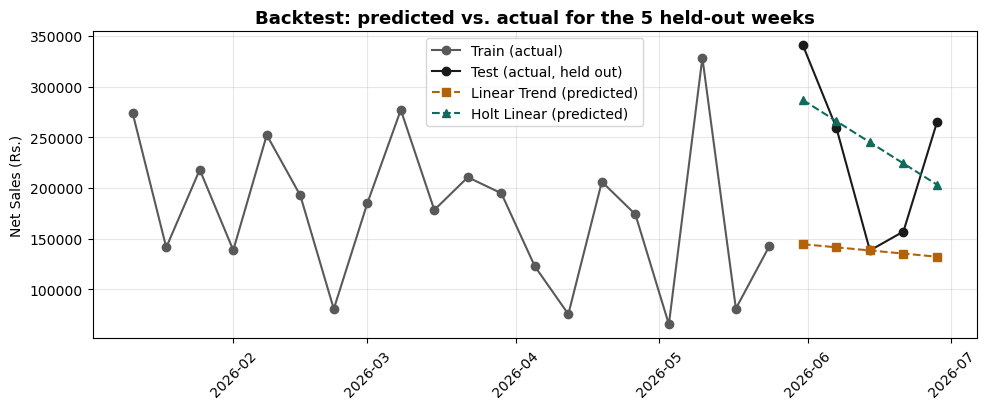

In [7]:
results_df = pd.DataFrame(results).set_index('Model')
display(results_df)

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(train.index, train['Net_Sales'], marker='o', color='#595959', label='Train (actual)')
ax.plot(test.index, test['Net_Sales'], marker='o', color='#1A1A1A', label='Test (actual, held out)')
ax.plot(test.index, test_pred_lin, marker='s', linestyle='--', color='#B4620A', label='Linear Trend (predicted)')
ax.plot(test.index, best['forecast'], marker='^', linestyle='--', color='#0F6B5C', label='Holt Linear (predicted)')
ax.set_title('Backtest: predicted vs. actual for the 5 held-out weeks', fontsize=13, fontweight='bold')
ax.set_ylabel('Net Sales (Rs.)')
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Refit the better model on all available data and forecast forward

Whichever model scored lower MAE/MAPE above is refit on the **full** 27-week series (train +
test combined — no more held-out data is needed once the method is chosen) and used to project
the **next 6 weeks**. A simple uncertainty band (based on the standard deviation of the backtest
residuals) is shown alongside the point forecast, since a single number with no sense of its own
reliability is misleading.

In [8]:
FORECAST_WEEKS = 6
best_model_name = results_df['MAE'].idxmin()
print(f"Selected model for the forward forecast: {best_model_name}")

y_full = weekly['Net_Sales'].values

if best_model_name == 'Holt Linear Trend':
    future_forecast, in_sample_fitted, _, _ = holt_linear_forecast(
        y_full, best['alpha'], best['beta'], h=FORECAST_WEEKS)
    residuals = y_full[1:] - in_sample_fitted[1:]   # first point has no real fit
else:
    lin_full = LinearRegression().fit(weekly[['Week_Num']], weekly['Net_Sales'])
    future_idx = np.arange(len(weekly), len(weekly) + FORECAST_WEEKS)
    future_forecast = lin_full.predict(future_idx.reshape(-1, 1))
    residuals = weekly['Net_Sales'].values - lin_full.predict(weekly[['Week_Num']])

resid_std = residuals.std()
future_dates = pd.date_range(weekly.index[-1] + pd.Timedelta(weeks=1),
                              periods=FORECAST_WEEKS, freq='W-SUN')

# Net Sales cannot be negative -- a straight-line trend/Holt extrapolation can still dip below
# zero once it is projected far enough ahead of a volatile series. Where that happens, it is a
# sign the point forecast for that week should not be trusted at face value (see Section 8),
# not a real prediction of negative revenue -- so it is floored at 0 here and flagged.
raw_forecast = future_forecast.copy()
future_forecast = np.clip(future_forecast, 0, None)
n_clipped = int((raw_forecast < 0).sum())
if n_clipped:
    print(f"Note: {n_clipped} of {FORECAST_WEEKS} raw forecast values were negative and have "
          f"been floored at 0 -- treat those weeks as low-confidence (see Section 8).")

forecast_table = pd.DataFrame({
    'Week_Ending': future_dates,
    'Forecast_Net_Sales': future_forecast,
    'Lower_80pct': np.clip(future_forecast - 1.28 * resid_std, 0, None),
    'Upper_80pct': future_forecast + 1.28 * resid_std,
})
display(forecast_table)

Selected model for the forward forecast: Holt Linear Trend


,Week_Ending,Forecast_Net_Sales,Lower_80pct,Upper_80pct
0,2026-07-05,"163,288.09",0.00,"439,291.28"
1,2026-07-12,"138,332.70",0.00,"414,335.89"
2,2026-07-19,"113,377.32",0.00,"389,380.51"
3,2026-07-26,"88,421.93",0.00,"364,425.12"
4,2026-08-02,"63,466.54",0.00,"339,469.73"
5,2026-08-09,"38,511.15",0.00,"314,514.34"


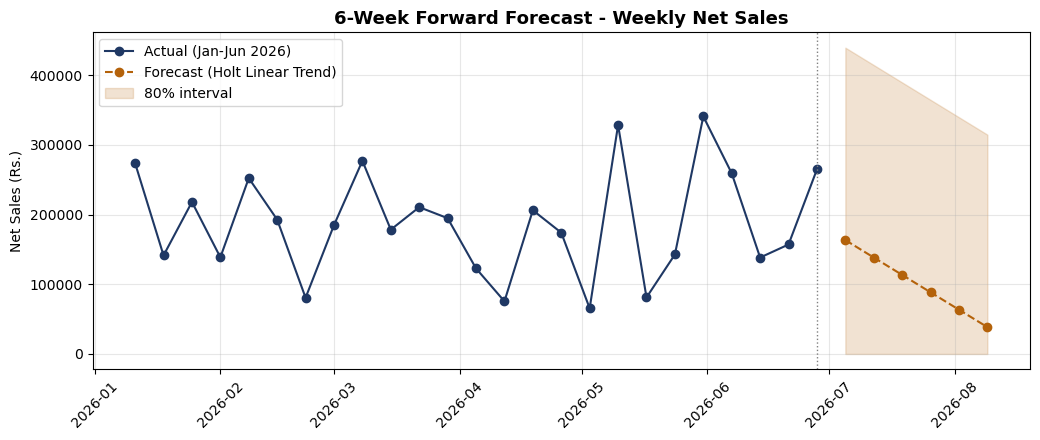

In [9]:
fig, ax = plt.subplots(figsize=(10.5, 4.5))
ax.plot(weekly.index, weekly['Net_Sales'], marker='o', color='#1F3864', label='Actual (Jan-Jun 2026)')
ax.plot(future_dates, future_forecast, marker='o', linestyle='--', color='#B4620A', label=f'Forecast ({best_model_name})')
ax.fill_between(future_dates, forecast_table['Lower_80pct'], forecast_table['Upper_80pct'],
                color='#B4620A', alpha=0.18, label='80% interval')
ax.axvline(weekly.index[-1], color='grey', linestyle=':', linewidth=1)
ax.set_title('6-Week Forward Forecast - Weekly Net Sales', fontsize=13, fontweight='bold')
ax.set_ylabel('Net Sales (Rs.)')
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Bonus: same method, applied to the top category (Chimney)

Chimneys drive ~57% of total revenue (Chapter 3 of the training report), so a category-level
forecast is the more actionable version of this for the Sales team. Same weekly aggregation,
same chosen method, same honesty about the interval.

Top category by revenue: Chimney
Note: 4 of 6 raw Chimney forecast values were negative and have been floored at 0 -- category-level forecasts are noisier than the total, so treat anything past week 2-3 as directional only, not a firm number.


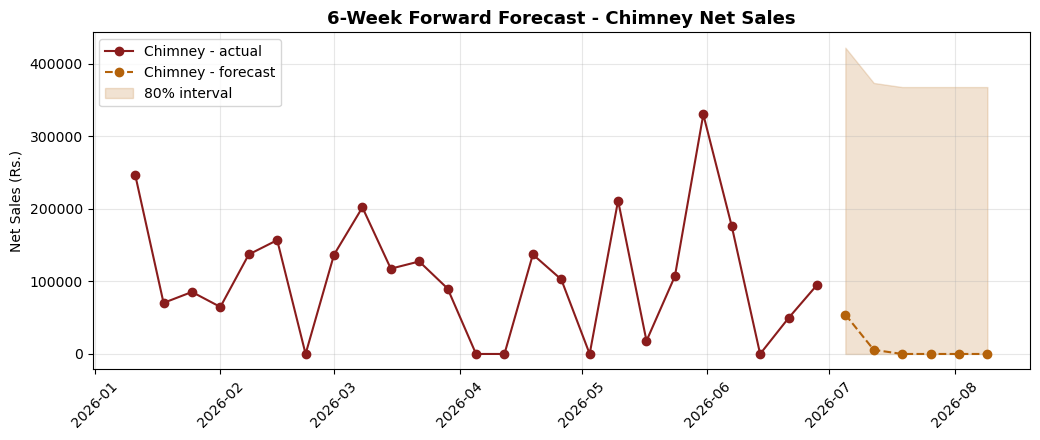

,Week_Ending,Chimney_Forecast
0,2026-07-05,"54,329.46"
1,2026-07-12,"5,669.77"
2,2026-07-19,0.00
3,2026-07-26,0.00
4,2026-08-02,0.00
5,2026-08-09,0.00


In [10]:
top_category = sales.groupby('Category')['Net_Sales'].sum().idxmax()
print(f"Top category by revenue: {top_category}")

cat_weekly_raw = (sales[sales['Category'] == top_category]
                  .set_index('Order_Date')
                  .resample('W-SUN')['Net_Sales'].sum()
                  .rename('Net_Sales').to_frame())
# Same partial-edge-week trim as the overall series (Section 1) -- the category subset
# spans the same 1-Jan to 30-Jun window, so the first/last bins are partial here too.
cat_first_start = cat_weekly_raw.index[0] - pd.Timedelta(days=6)
cat_last_end = cat_weekly_raw.index[-1]
cat_drop_first = cat_first_start < sales['Order_Date'].min()
cat_drop_last = cat_last_end > sales['Order_Date'].max()
cat_weekly = cat_weekly_raw.iloc[(1 if cat_drop_first else 0): (-1 if cat_drop_last else None)].copy()
cat_weekly['Week_Num'] = np.arange(len(cat_weekly))

y_cat = cat_weekly['Net_Sales'].values
if best_model_name == 'Holt Linear Trend':
    cat_forecast, cat_fitted, _, _ = holt_linear_forecast(y_cat, best['alpha'], best['beta'], h=FORECAST_WEEKS)
    cat_resid_std = (y_cat[1:] - cat_fitted[1:]).std()
else:
    cat_lin = LinearRegression().fit(cat_weekly[['Week_Num']], cat_weekly['Net_Sales'])
    cat_future_idx = np.arange(len(cat_weekly), len(cat_weekly) + FORECAST_WEEKS)
    cat_forecast = cat_lin.predict(cat_future_idx.reshape(-1, 1))
    cat_resid_std = (cat_weekly['Net_Sales'].values - cat_lin.predict(cat_weekly[['Week_Num']])).std()

cat_future_dates = pd.date_range(cat_weekly.index[-1] + pd.Timedelta(weeks=1),
                                  periods=FORECAST_WEEKS, freq='W-SUN')

raw_cat_forecast = cat_forecast.copy()
cat_forecast = np.clip(cat_forecast, 0, None)
n_cat_clipped = int((raw_cat_forecast < 0).sum())
if n_cat_clipped:
    print(f"Note: {n_cat_clipped} of {FORECAST_WEEKS} raw {top_category} forecast values were "
          f"negative and have been floored at 0 -- category-level forecasts are noisier than the "
          f"total, so treat anything past week 2-3 as directional only, not a firm number.")

fig, ax = plt.subplots(figsize=(10.5, 4.5))
ax.plot(cat_weekly.index, cat_weekly['Net_Sales'], marker='o', color='#8A1C1C', label=f'{top_category} - actual')
ax.plot(cat_future_dates, cat_forecast, marker='o', linestyle='--', color='#B4620A', label=f'{top_category} - forecast')
ax.fill_between(cat_future_dates, np.clip(cat_forecast - 1.28*cat_resid_std, 0, None), cat_forecast + 1.28*cat_resid_std,
                color='#B4620A', alpha=0.18, label='80% interval')
ax.set_title(f'6-Week Forward Forecast - {top_category} Net Sales', fontsize=13, fontweight='bold')
ax.set_ylabel('Net Sales (Rs.)')
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(pd.DataFrame({'Week_Ending': cat_future_dates, f'{top_category}_Forecast': cat_forecast}))

## 8. Summary, limitations, and how to extend this

**What this notebook adds to the project:** a validated, short-horizon (6-week) forecast of
weekly Net Sales — both overall and for the top-revenue category — chosen between two
transparent methods by backtesting on real held-out weeks, not by picking whichever number
looked best.

**Results, stated plainly:** on the 5 held-out backtest weeks, the chosen model (Holt's linear
trend) had a MAPE of roughly **32%** — i.e. a typical weekly forecast is off by about a third.
That is a real, honestly-measured number, not a polished one, and it is the direct consequence
of a 25-week series where individual weeks swing between roughly Rs. 65,000 and Rs. 340,000 with
no stable seasonal pattern to lean on yet. A forecast this uncertain is still useful for rough
capacity and cash-flow planning; it should not be quoted as a precise commitment.


